In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
!ls ../artifacts/datasets/

dataset_level_09_daily_store_dept.parquet


In [3]:
#results_df = pd.read_parquet('../output/experiment_results.parquet')
#results_df.sort_values('wape').head(10)

# Data

In [4]:
LEVEL = 'level_09_daily_store_dept'

In [5]:
df = pd.read_parquet(f'../artifacts/datasets/dataset_{LEVEL}.parquet')

df = df.sort_values("date").copy()

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-29,297.0,681.179993,2.293535,NaN,NaN,0.991603,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,1533.0,3305.0,5047.0,6652.0,8373.0,10069.0,75935.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97050,HOUSEHOLD_1_HOUSEHOLD_CA_1_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,2011-01-29,361.0,1409.290039,3.903850,NaN,NaN,1.002209,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2143.0,4003.0,6065.0,8223.0,10286.0,12291.0,123596.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27174,FOODS_2_FOODS_TX_1_TX,TOTAL,FOODS_2,FOODS,TX_1,TX,2011-01-29,390.0,1193.359985,3.059897,NaN,NaN,0.933859,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2659.0,5183.0,7548.0,9379.0,11639.0,14332.0,124580.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98991,HOUSEHOLD_1_HOUSEHOLD_CA_2_CA,TOTAL,HOUSEHOLD_1,HOUSEHOLD,CA_2,CA,2011-01-29,529.0,2115.379883,3.998828,NaN,NaN,1.026361,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,2388.0,4869.0,7210.0,9707.0,11927.0,14439.0,145585.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25233,FOODS_2_FOODS_CA_4_CA,TOTAL,FOODS_2,FOODS,CA_4,CA,2011-01-29,351.0,1046.400024,2.981197,NaN,NaN,0.901778,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,1845.0,3654.0,5408.0,7130.0,9040.0,10951.0,95545.0,1.0,0,NaN,8.0,NaN,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

# Variables

In [6]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS  # derivadas de sales (targets de otros horizontes), fuera de FEATURES

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES))

87


# Split

In [7]:
VALID_MONTHS = 18
TEST_MONTHS = 6

first_date = df["date"].min()
last_date = df["date"].max()

test_start = last_date - pd.DateOffset(months=TEST_MONTHS)
valid_start = test_start - pd.DateOffset(months=VALID_MONTHS)

train = df[df["date"] < valid_start]
valid = df[(df["date"] >= valid_start) & (df["date"] < test_start)]
test = df[df["date"] >= test_start]

print(f"Dataset starts : {first_date:%Y-%m-%d} ({len(df):,} rows)")
print(f"Validation start : {valid_start:%Y-%m-%d} ({len(train):,} rows)")
print(f"Test start       : {test_start:%Y-%m-%d} ({len(valid):,} rows)")
print(f"Dataset ends   : {last_date:%Y-%m-%d} ({len(test):,} rows)")

Dataset starts : 2011-01-29 (135,870 rows)
Validation start : 2014-05-22 (84,630 rows)
Test start       : 2015-11-22 (38,430 rows)
Dataset ends   : 2016-05-22 (12,810 rows)


In [8]:
X_train = train[FEATURES].copy()
y_train = train[TARGET]

X_valid = valid[FEATURES].copy()
y_valid = valid[TARGET]

X_test = test[FEATURES].copy()
y_test = test[TARGET]

# Categorías unificadas a partir del dataset completo: evita que train/valid/test
# terminen con distintos sets de categorías (rompe modelos que validan categorías, p. ej. XGBoost)
for col in CATEGORICAL_FEATURES:
    categories = df[col].astype("category").cat.categories
    for X in (X_train, X_valid, X_test):
        X[col] = pd.Categorical(X[col], categories=categories)

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")

Cantidad features: 87 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [ ]:
from src.evaluation.metrics import wape, compute_wrmsse, clip_closed_stores

model_results = []

def evaluate_model(name, y_pred_valid):
    y_pred_valid = clip_closed_stores(valid, y_pred_valid)
    model_results.append({
        "model": name,
        "wape": wape(y_valid, y_pred_valid),
        "wrmsse": compute_wrmsse(train, valid, y_pred_valid),
    })
    print(f"{name:>25s} | WAPE: {model_results[-1]['wape']:.2%} | WRMSSE: {model_results[-1]['wrmsse']:.4f}")

## Baseline naive

In [ ]:
# Naive: repite la última venta observada por serie (día anterior al inicio de validación)
last_train_value = train.sort_values("date").groupby("agg_id")[TARGET].last()

y_pred_naive = valid["agg_id"].map(last_train_value).fillna(0.0).to_numpy()
evaluate_model("naive (last value)", y_pred_naive)

## Modelos

In [ ]:
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42

### LightGBM

In [ ]:
lgbm_model = lgb.LGBMRegressor(
    objective="l1",
    random_state=RANDOM_STATE,
    verbosity=-1,
)
lgbm_model.fit(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES)

evaluate_model("LightGBM", lgbm_model.predict(X_valid))

### XGBoost

In [ ]:
xgb_model = XGBRegressor(
    objective="reg:absoluteerror",
    tree_method="hist",
    enable_categorical=True,
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)

evaluate_model("XGBoost", xgb_model.predict(X_valid))

### CatBoost

In [ ]:
# CatBoost necesita las categóricas como string sin NaN (no soporta el dtype category de pandas con nulos)
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
for X in (X_train_cb, X_valid_cb):
    for col in CATEGORICAL_FEATURES:
        X[col] = X[col].astype(str).fillna("missing")

catboost_model = CatBoostRegressor(
    loss_function="MAE",
    random_state=RANDOM_STATE,
    cat_features=CATEGORICAL_FEATURES,
    verbose=False,
)
catboost_model.fit(X_train_cb, y_train)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb))

### HistGradientBoosting (sklearn)

In [ ]:
hgb_model = HistGradientBoostingRegressor(
    loss="absolute_error",
    categorical_features="from_dtype",
    random_state=RANDOM_STATE,
)
hgb_model.fit(X_train, y_train)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid))

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

ridge_model = make_pipeline(SimpleImputer(strategy="median"), Ridge(random_state=RANDOM_STATE))
ridge_model.fit(X_train[NUMERICAL_FEATURES], y_train)

evaluate_model("Ridge (solo numéricas)", ridge_model.predict(X_valid[NUMERICAL_FEATURES]))

## Resultados

In [ ]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(results_df, x="wrmsse", y="model", ax=ax)
ax.set_title("WRMSSE por modelo (validación)", loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

# Modelo simple

In [9]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from src.evaluation.metrics import compute_wrmsse, wape

def wape_metric(y_true, y_pred):
    score = wape(y_true, y_pred)
    return "wape", score, False  # menor es mejor

def wrmsse_metric(y_true, y_pred):
    score = compute_wrmsse(train, valid, y_pred)
    return "wrmsse", score, False

In [10]:
model = LGBMRegressor(
    objective="l1",
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15603
[LightGBM] [Info] Number of data points in the train set: 84630, number of used features: 86
[LightGBM] [Info] Start training from score 264.000000
Training until validation scores don't improve for 100 rounds
[10]	valid_0's l1: 171.965	valid_0's wrmsse: 1.69722
[20]	valid_0's l1: 91.2015	valid_0's wrmsse: 1.0417
[30]	valid_0's l1: 65.6544	valid_0's wrmsse: 0.795315
[40]	valid_0's l1: 58.1123	valid_0's wrmsse: 0.710341
[50]	valid_0's l1: 55.4689	valid_0's wrmsse: 0.675157
[60]	valid_0's l1: 54.2537	valid_0's wrmsse: 0.658481
[70]	valid_0's l1: 53.3438	valid_0's wrmsse: 0.647189
[80]	valid_0's l1: 52.5639	valid_0's wrmsse: 0.637943
[90]	valid_0's l1: 52.1177	valid_0's wrmsse: 0.632971
[100]	valid_0's l1: 51.5654	valid_0's wrmsse: 0.625398
Did not meet early stopping. Best iteration is:
[100]	v

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Explicación modelo

In [11]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [12]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                              feature  mean_abs_shap
33                               lag1     182.917528
36                               lag7      87.454041
39                              lag28      38.239769
38                              lag21      31.112770
37                              lag14      26.287434
..                                ...            ...
29                            quarter       0.000000
28                   event_type_2_enc       0.000000
30                     is_month_start       0.000000
80  rolling_mean_lag364_window_size91       0.000000
85  rolling_mean_lag365_window_size28       0.000000

[87 rows x 2 columns]


### Importancia global de features

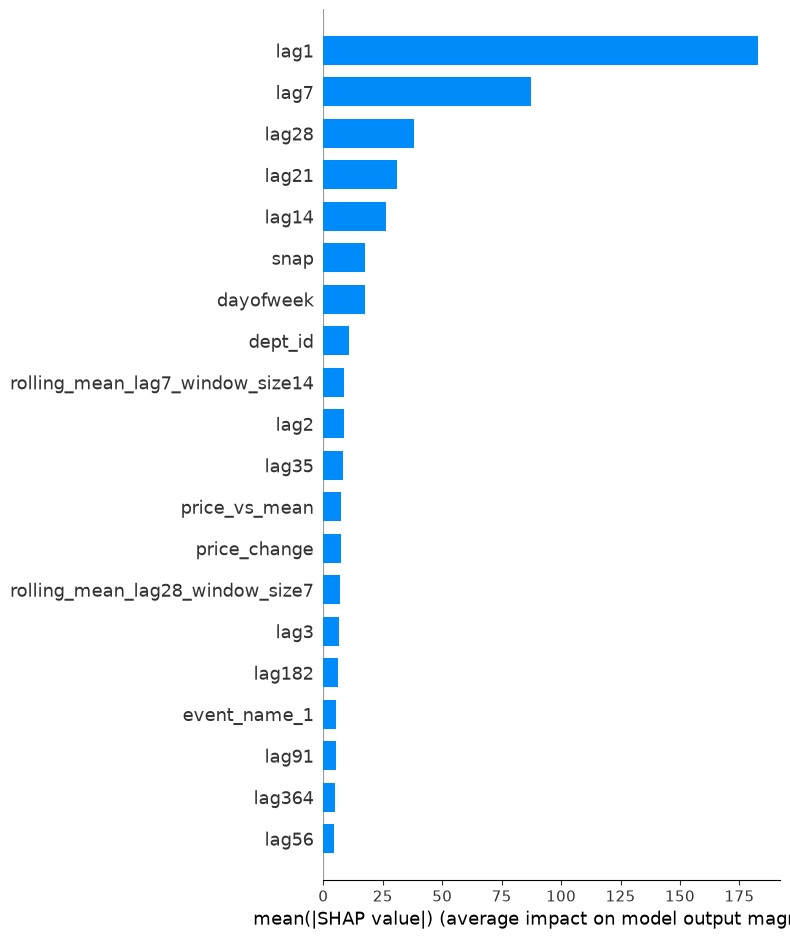

In [14]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

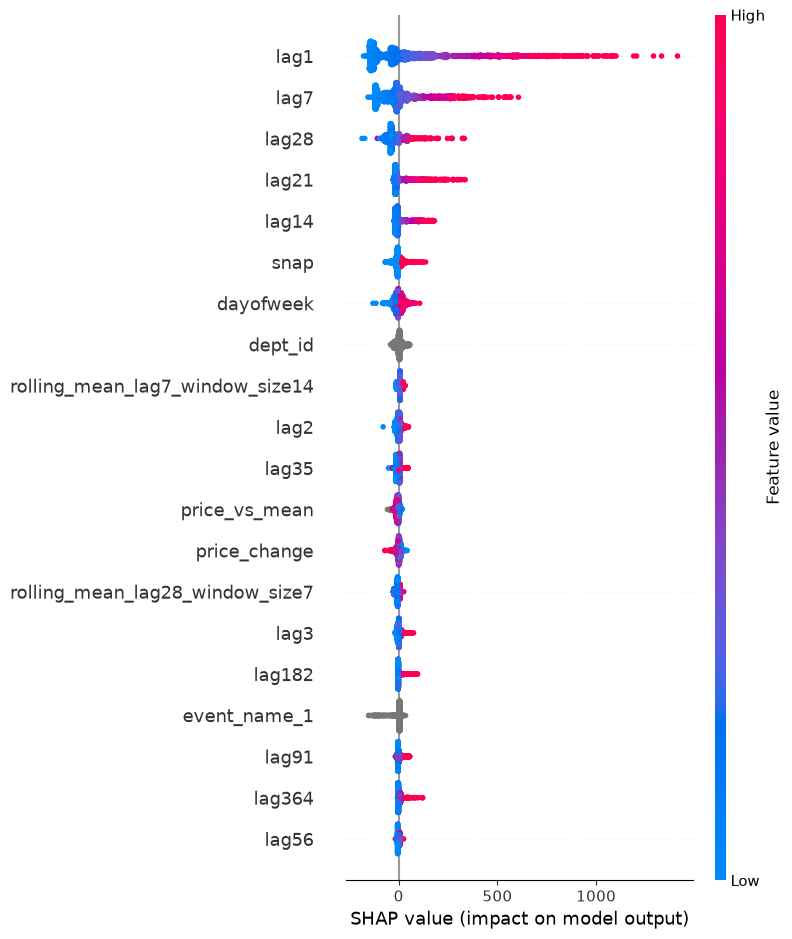

In [15]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag1


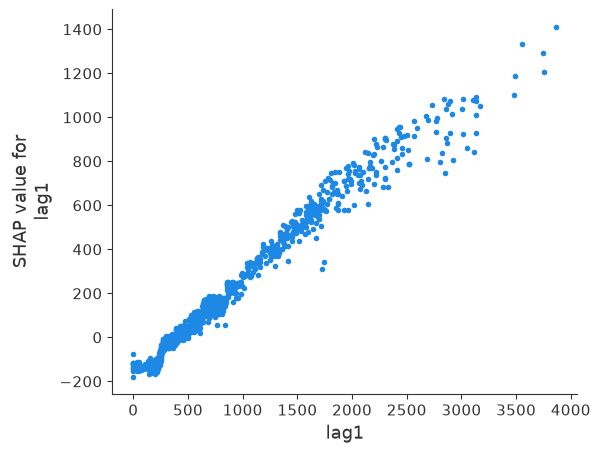

In [16]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

# Predicciones

In [17]:
def explain_prediction(agg_id, date, max_display=10):
    row_mask = (test["agg_id"] == agg_id) & (test["date"] == date)
    row_idx = test.index[row_mask][0]

    row = X_test.loc[[row_idx]]
    row_shap_values = explainer.shap_values(row)

    info = df_pred.loc[row_idx, ["agg_id", "date", TARGET, "y_pred", "error"]]

    agg_id_val = info["agg_id"]
    date_val = info["date"]
    sales_val = info[TARGET]
    pred_val = info["y_pred"]
    error_val = info["error"]
    error_pct = (error_val / sales_val * 100) if sales_val != 0 else float("nan")

    shap.plots.waterfall(
        shap.Explanation(
            values=row_shap_values[0],
            base_values=explainer.expected_value,
            data=row.iloc[0],
            feature_names=row.columns,
        ),
        max_display=max_display,
        show=False,
    )
    plt.title(
        f"{agg_id_val} | {date_val:%Y-%m-%d} | "
        f"sales={sales_val:.0f} | pred={pred_val:.0f} | "
        f"error={error_val:.0f} ({error_pct:.1f}%)",
        pad=20,
        loc="left"
    )
    plt.show()

In [18]:
def plot_forecast(agg_id, n=30, date=None):
    df_plot = df_pred[df_pred['agg_id'] == agg_id].copy()
    if date:
        date = pd.Timestamp(date)
        since = date - pd.Timedelta(days=n)
        until = date + pd.Timedelta(days=n)
        df_plot = df_plot[(df_plot['date'] >= since) & (df_plot['date'] <= until)]

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.lineplot(df_plot, x='date', y=TARGET, label='Real', ax=ax)
    sns.lineplot(df_plot, x='date', y='y_pred', label='Predicción', ax=ax)
    if date:
        ax.axvline(date, color='red', linestyle='--', linewidth=1)

    ax.set_title(agg_id, loc='left')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [19]:
def analizar_prediccion(agg_id, date=None, max_display=10):
    plot_forecast(agg_id, date=date)
    if date:
        explain_prediction(agg_id, date, max_display=max_display)

In [20]:
from src.evaluation.metrics import clip_closed_stores

y_pred = clip_closed_stores(test, model.predict(X_test))

wape_test = wape(y_test, y_pred)
wrmsse_test = compute_wrmsse(train, test, y_pred)

print(f"Test WAPE: {wape_test:.2%}")
print(f"Test WRMSSE: {wrmsse_test:.4f}")

Test WAPE: 10.35%
Test WRMSSE: 0.7103


In [21]:
df_pred = test.copy()
df_pred["y_pred"] = y_pred.round(0).astype(float)
df_pred["error"] = df_pred[TARGET] - df_pred["y_pred"]
df_pred["abs_error"] = np.abs(df_pred["error"])

df_pred["wape"] = df_pred["abs_error"] / df_pred[TARGET].abs()
df_pred["bias"] = -df_pred["error"] / df_pred[TARGET].abs()

df_pred = df_pred[["agg_id", "date", TARGET, "gross_sales", "y_pred", "error", "abs_error", "wape", "bias"]].sort_values("abs_error")

In [22]:
from src.evaluation.metrics import compute_scales, bias

def _wrmsse_for_group(g):
    scale = scales.get(g.name)
    if not scale:
        return np.nan
    weights = g.groupby(WEIGHT_LEVEL)["gross_sales"].transform("sum").to_numpy()
    sq_err = (g[TARGET].to_numpy() - g["y_pred"].to_numpy()) ** 2
    rmse = np.sqrt(np.average(sq_err, weights=weights))
    return float(rmse / np.sqrt(scale))

# Nivel de ponderación del error dentro del WRMSSE por serie:
# ["agg_id"]         -> sin ponderación real (peso constante = total de la serie, igual a RMSSE)
# ["date"]           -> pondera cada fecha por su gross_sales (días de más venta pesan más)
# ["agg_id", "date"] -> pondera cada fila por su propio gross_sales (equivalente a ["date"] a nivel serie)
WEIGHT_LEVEL = ["date"]

scales = compute_scales(train)

by_series = df_pred.groupby("agg_id")
wape_by_series = by_series.apply(lambda g: wape(g[TARGET], g["y_pred"]))
bias_by_series = by_series.apply(lambda g: bias(g[TARGET], g["y_pred"]))
sales_by_series = by_series[TARGET].sum()
gross_sales_by_series = by_series["gross_sales"].sum()

wrmsse_by_series = by_series.apply(_wrmsse_for_group)

df_metrics = pd.DataFrame({
    "sales": sales_by_series,
    "gross_sales": gross_sales_by_series,
    "gross_sales_pct": gross_sales_by_series / df_pred["gross_sales"].sum(),
    "wape": wape_by_series,
    "bias": bias_by_series,
    "wrmsse": wrmsse_by_series,
})

df_metrics = df_metrics.sort_values("gross_sales", ascending=False)
df_metrics.head(10)

,sales,gross_sales,gross_sales_pct,wape,bias,wrmsse
agg_id,,,,,,
FOODS_3_FOODS_CA_3_CA,502039.0,1.229614e+06,0.052515,0.075948,-0.011647,0.560538
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,246533.0,9.737667e+05,0.041588,0.073236,-0.019580,0.714255
FOODS_3_FOODS_CA_1_CA,372378.0,9.440146e+05,0.040317,0.078694,-0.035518,0.472749
FOODS_3_FOODS_WI_2_WI,390016.0,8.735404e+05,0.037307,0.095053,-0.048685,0.776218
FOODS_3_FOODS_CA_2_CA,329778.0,8.262919e+05,0.035290,0.105583,-0.054585,0.967653
FOODS_3_FOODS_TX_2_TX,340755.0,8.060413e+05,0.034425,0.083292,-0.032804,0.497161
FOODS_3_FOODS_WI_3_WI,352170.0,7.707222e+05,0.032916,0.083781,-0.036519,0.488214
FOODS_3_FOODS_TX_3_TX,300537.0,7.185836e+05,0.030689,0.085347,-0.036202,0.595189
FOODS_3_FOODS_WI_1_WI,297050.0,7.138724e+05,0.030488,0.095657,-0.042899,0.765583


In [23]:
df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
44494,FOODS_3_FOODS_CA_3_CA,2015-12-26,2312.0,5882.390137,1205.0,1107.0,1107.0,0.478806,-0.478806
44465,FOODS_3_FOODS_CA_3_CA,2015-11-27,1731.0,3807.770020,2338.0,-607.0,607.0,0.350664,0.350664
44587,FOODS_3_FOODS_CA_3_CA,2016-03-28,2433.0,6011.709961,3105.0,-672.0,672.0,0.276202,0.276202
44522,FOODS_3_FOODS_CA_3_CA,2016-01-23,3555.0,8466.379883,2644.0,911.0,911.0,0.256259,-0.256259
44521,FOODS_3_FOODS_CA_3_CA,2016-01-22,2384.0,5561.729980,1818.0,566.0,566.0,0.237416,-0.237416
44499,FOODS_3_FOODS_CA_3_CA,2015-12-31,2682.0,6914.830078,2064.0,618.0,618.0,0.230425,-0.230425
44500,FOODS_3_FOODS_CA_3_CA,2016-01-01,2038.0,4981.200195,1578.0,460.0,460.0,0.225711,-0.225711
44492,FOODS_3_FOODS_CA_3_CA,2015-12-24,1814.0,4859.919922,2213.0,-399.0,399.0,0.219956,0.219956
44514,FOODS_3_FOODS_CA_3_CA,2016-01-15,2433.0,5935.439941,1933.0,500.0,500.0,0.205508,-0.205508
44508,FOODS_3_FOODS_CA_3_CA,2016-01-09,3666.0,8605.000000,2932.0,734.0,734.0,0.200218,-0.200218


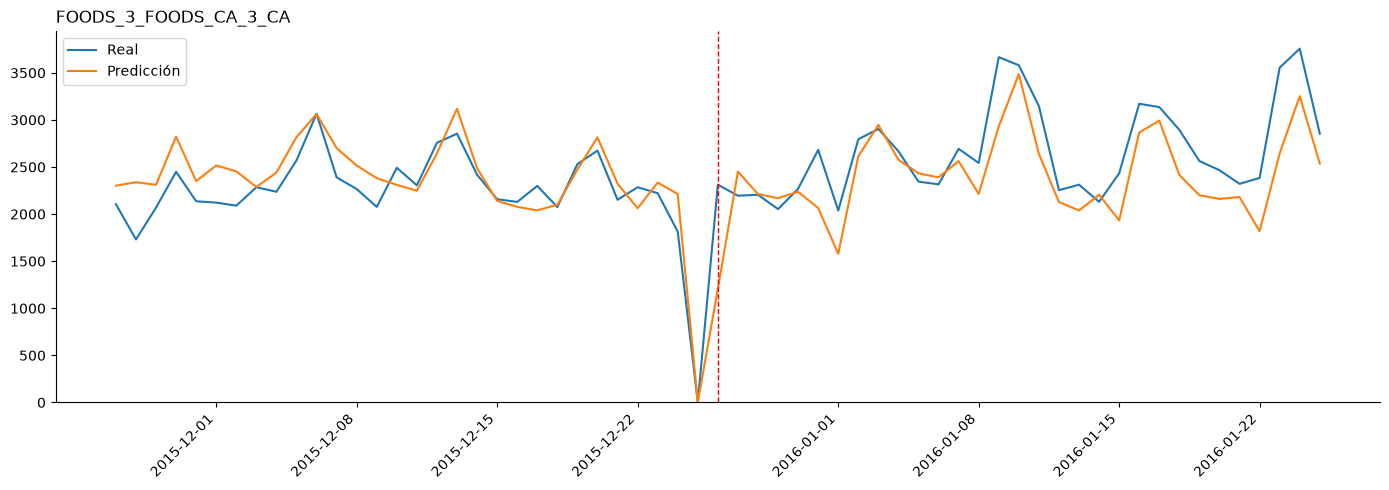

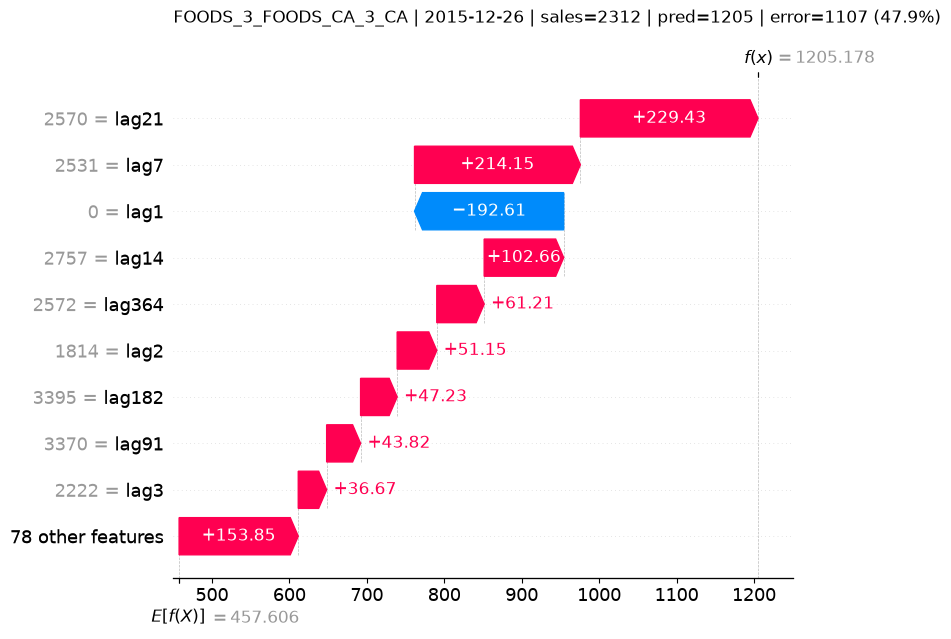

In [ ]:
analizar_prediccion('FOODS_3_FOODS_CA_3_CA', '2015-12-26', max_display=20)

# Modelo optimizado

In [25]:
import optuna
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb
import numpy as np

In [26]:
import lightgbm as lgb
import numpy as np
import optuna
from optuna.integration import LightGBMPruningCallback

In [27]:
def objective(trial):
    model = lgb.LGBMRegressor(
        objective="tweedie",
        tweedie_variance_power=trial.suggest_float("tweedie_variance_power", 1.1, 1.4),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        n_estimators=3000,
        num_leaves=trial.suggest_int("num_leaves", 31, 512),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 300),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=wrmsse_metric,
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(50, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, "wrmsse"),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    
    return final_wrmsse

In [28]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
        multivariate=True,
        group=True,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(
    objective,
    n_trials=50,
    timeout=120,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

/tmp/ipykernel_17771/3864358102.py:6: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_17771/3864358102.py:6: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-08-20 21:03:27,109] Using an existing study with name 'study_level_09_daily_store_dept' instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-20 21:03:31,847] Trial 48 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:03:37,289] Trial 49 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:03:52,730] Trial 50 pruned. Trial was pruned at iteration 40.
[I 2026-08-20 21:04:02,301] Trial 51 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:04:14,267] Trial 52 pruned. Trial was pruned at iteration 39.
[I 2026-08-20 21:04:18,604] Trial 53 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:04:22,312] Trial 54 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:04:25,685] Trial 55 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:04:36,206] Trial 56 pruned. Trial was pruned at iteration 22.
[I 2026-08-20 21:04:39,928] Trial 57 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:04:43,327] Trial 58 pruned. Trial was pruned at iteration 10.
[I 2026-08-20 21:04:55,055] Trial 59 pruned. Trial was pruned at iteration 45.
[I 2026-08-20 21:04:58,625] Trial 60 pruned. Trial w

# Modelo final

In [29]:
model_params = {
    k: v for k, v in best_trial.params.items()
    if not k.startswith("use_")
}

# with open("best_params.json", "w") as f:
#     json.dump(model_params, f, indent=2)

final_model = lgb.LGBMRegressor(
    objective="l1",
    n_estimators=5000,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=cat_cols,
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),
        lgb.log_evaluation(0),
    ],
)

final_model.booster_.save_model("final_model.txt")

NameError: name 'cat_cols' is not defined